### Задание

Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)


In [17]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline
from sklearn.model_selection import train_test_split

In [18]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [29]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -qo hw_pro.zip

In [32]:
# Путь к директории с базой
base_dir = "hw_pro"
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                         target_size=(img_height, img_width),
                                                         color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        else:
            y_train.append(1)
# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Разделение на train и test
x_train, x_test, y_train, y_test = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)
print('Размер массива x_tеst', x_test.shape)
print('Размер массива y_test', y_test.shape)

Размер массива x_train (81, 20, 20, 1)
Размер массива y_train (81,)
Размер массива x_tеst (21, 20, 20, 1)
Размер массива y_test (21,)


Разворачиваем изображение в вектор, проводим нормализация пикселей

In [31]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train.astype('float32') / 255
x_test =  x_test.astype('float32') / 255
print(f'Форма обучающих данных: {x_train.shape}')
print(f'Форма  тестовых данных: {x_test.shape}')

Форма обучающих данных: (81, 400)
Форма  тестовых данных: (21, 400)


Задаем количество классов

In [22]:
CLASS_COUNT = 2

Преобразование в формат one_hot_encoding

In [23]:
y_train = utils.to_categorical(y_train, CLASS_COUNT)
y_test = utils.to_categorical(y_test, CLASS_COUNT)


Создаём и настраиваем модель, задаём функцию потерь, оптимизатор и метрику точности

In [24]:
model = Sequential()

model.add(Dense(400, input_dim = 400, activation = 'relu'))

model.add(Dense(200, activation='relu'))

model.add(Dense(CLASS_COUNT, activation='softmax'))

# Компиляция модели
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Вывод структуры модели
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,002 (941.41 KB)

 Trainable params: 241,002 (941.41 KB)

 Non-trainable params: 0 (0.00 B)

None


Обучаем модель

In [25]:
model.fit(x_train, y_train, batch_size = 8, epochs = 11, verbose = 1)

Epoch 1/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5843 - loss: 0.8231
Epoch 2/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8883 - loss: 0.4911
Epoch 3/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5771 - loss: 0.7953 
Epoch 4/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7557 - loss: 0.3909 
Epoch 5/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8266 - loss: 0.3029 
Epoch 6/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8351 - loss: 0.2948 
Epoch 7/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1061 
Epoch 8/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0587 
Epoch 9/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0509 
Epoch 10/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0336 
Epoch 11/11
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0271 


Проверим работу модели

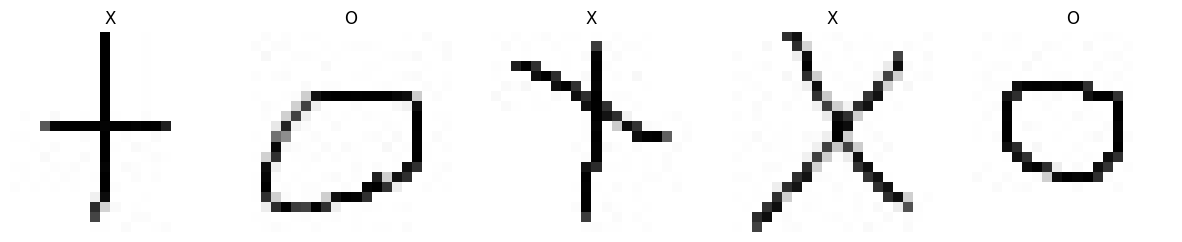

In [26]:
plt.figure(figsize=(15,3))

for i in range(5):
    n_rec = np.random.randint(x_train.shape[0])

    plt.subplot(1,5,i+1)
    plt.imshow(x_train[n_rec].reshape(20,20), cmap='gray')

    x = x_train[n_rec].reshape(1,400).astype("float32")
    pred = np.argmax(model.predict(x, verbose=0))

    plt.title("X" if pred == 1 else "O")
    plt.axis("off")

plt.show()

In [27]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Точность:", accuracy)

Точность: 1.0
